In [13]:
!pip install pinecone-client cohere

In [14]:
import pandas as pd
import cohere
from pinecone import Pinecone, ServerlessSpec

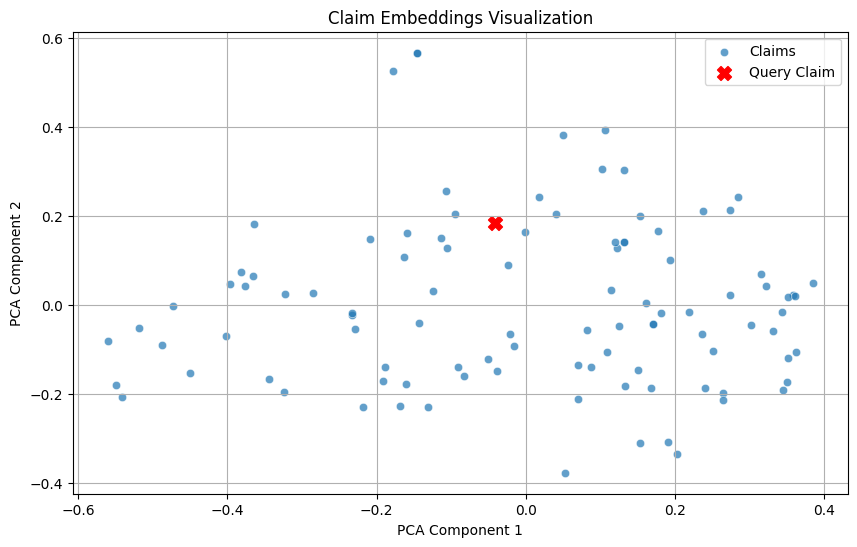

In [17]:
import time
import os
import logging
import pandas as pd
import cohere
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from pinecone import Pinecone, ServerlessSpec

# Configure logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Load API keys from environment variables
COHERE_API_KEY = os.getenv("COHERE_API_KEY", "ZuYJxGhI3YxFDL0cMl9nxMDGk6FPoTjVt1LvoUxs")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY", "pcsk_2LRQQL_DaYUAiyaXJBF5CqrsjPRUeRVMQnWwxnut2KMYDorn2FqCf7NBN7TDUtvk8xaXWi")

# Initialize clients
cohere_client = cohere.Client(api_key=COHERE_API_KEY)
pc = Pinecone(api_key=PINECONE_API_KEY)

# Define constants
INDEX_NAME = "insurance-claims"
BATCH_SIZE = 10
EMBED_MODEL = "embed-english-v3.0"
PINECONE_DIMENSION = 1024

# Load dataset
df = pd.read_csv("/content/sample_data/insurance_claims_top_100.csv")

def initialize_pinecone():
    """Initialize Pinecone index."""
    existing_indexes = [index_info["name"] for index_info in pc.list_indexes()]
    if INDEX_NAME not in existing_indexes:
        pc.create_index(
            INDEX_NAME,
            dimension=PINECONE_DIMENSION,
            metric="euclidean",
            spec=ServerlessSpec(cloud="aws", region="us-east-1"),
        )
        logging.info(f"Created Pinecone index: {INDEX_NAME}")
    return pc.Index(INDEX_NAME)

def get_embeddings(text_list):
    """Batch embeddings request to Cohere API with exponential backoff."""
    max_retries = 3
    delay = 10
    for attempt in range(max_retries):
        try:
            response = cohere_client.embed(texts=text_list, model=EMBED_MODEL, input_type="search_document")
            return response.embeddings
        except cohere.TooManyRequestsError:
            logging.warning(f"Rate limit reached. Retrying in {delay} seconds...")
            time.sleep(delay)
            delay *= 2
        except Exception as e:
            logging.error(f"Error generating embeddings: {e}")
            return None
    return None

def upsert_to_pinecone(index):
    """Generate embeddings and insert into Pinecone in batches."""
    claims = []
    embeddings = []

    for i in range(0, len(df), BATCH_SIZE):
        batch = df.iloc[i:i + BATCH_SIZE]

        # Filter valid claims
        batch = batch[batch["ClaimDescription"].notna() & batch["ClaimDescription"].str.strip().ne("")]
        if batch.empty:
            continue

        texts = batch["ClaimDescription"].tolist()
        batch_embeddings = get_embeddings(texts)

        if batch_embeddings is None or len(batch_embeddings) != len(batch):
            logging.warning(f"Skipping batch due to mismatched embeddings. Expected {len(batch)}, got {len(batch_embeddings) if batch_embeddings else 'None'}")
            continue

        for claim_id, embedding in zip(batch["ClaimNumber"], batch_embeddings):
            claims.append((str(claim_id), embedding))
            embeddings.append(embedding)

        if claims:
            index.upsert(claims)
            logging.info(f"Upserted {len(claims)} records into Pinecone.")
            claims = []
            time.sleep(1)

    return np.array(embeddings)

def find_similar_claims(index, query, top_k=5):
    """Find similar claims based on query."""
    query_embedding = get_embeddings([query])
    if not query_embedding:
        logging.warning("Failed to get query embedding.")
        return None

    results = index.query(vector=query_embedding[0], top_k=top_k, include_metadata=True)
    return results

def plot_embeddings(embeddings, query_embedding=None, query_label=None):
    """Visualize embeddings using PCA."""
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=reduced_embeddings[:, 0], y=reduced_embeddings[:, 1], alpha=0.7, label="Claims")

    if query_embedding is not None:
        query_reduced = pca.transform([query_embedding])
        plt.scatter(query_reduced[:, 0], query_reduced[:, 1], color="red", label=query_label, s=100, marker="X")

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("Claim Embeddings Visualization")
    plt.legend()
    plt.grid(True)
    plt.show()

def main():
    """Main workflow."""
    index = initialize_pinecone()
    embeddings = upsert_to_pinecone(index)

    query = "Car accident with rear-end collision"
    logging.info(f"Searching for similar claims: {query}")

    results = find_similar_claims(index, query)

    if results and results.get("matches"):
        closest_claim_id = results["matches"][0]["id"]
        closest_claim_description = df[df["ClaimNumber"] == closest_claim_id]["ClaimDescription"].values[0]
        logging.info(f"Most similar claim: {closest_claim_description}")

        query_embedding = get_embeddings([query])
        plot_embeddings(embeddings, query_embedding[0], query_label="Query Claim")
    else:
        logging.info("No similar claims found.")

if __name__ == "__main__":
    main()
